# Unified Simulation Analysis – Corrected for Accurate Validation

This notebook analyses simulation output (snapshot CSV) from your ABM, which uses the **Komi et al. 2025 ODE‑consistent model** with **temperature‑dependent adult mortality**. Parameters are loaded directly from the YAML file to ensure consistency.

**Key improvements**
- λ_max computed with **exact same temperature‑dependent adult mortality** as the simulation.
- Stage durations estimated via **cross‑correlation** (peak‑to‑peak) when possible, otherwise using theoretical values at mean temperature.
- Environmental correlation uses available climate data from snapshots.
- Suitability maps created using KDE on adult points and rasterised tank load.
- Validation against GBIF/iNaturalist occurrences (if provided).

**Assumptions**
- Ticks per day = 96 (15‑minute ticks).
- Livestock density fixed at 0.5 for λ_max (consistent with simulation’s default).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy.spatial import cKDTree
from scipy.stats import pearsonr, spearmanr
from scipy.signal import correlate, correlation_lags
from sklearn.neighbors import KernelDensity
from scipy.interpolate import RegularGridInterpolator
import rasterio
from rasterio.transform import from_origin
import os
import warnings
warnings.filterwarnings('ignore')

# ======================================================================
# CONFIGURATION – EDIT THESE PATHS
# ======================================================================
INPUT_FILE = "/home/void/Documents/codes/monadvsim/results/merged_snapshots_20260504_040223.csv"
STUDY_AREA_FILE = "/home/void/Documents/codes/monadvsim/prepared_data/somali/somali.shp"
OUTPUT_DIR = "/mnt/monadworld/projects/phd/article_manuscripts/new/figs/somali"
OCCURRENCE_FILE = "prepared_data/ethiopia_occurrence/merged_observations.csv"

# Simulation parameters
TICKS_PER_DAY = 96
CHUNKSIZE = 100000
MAX_SPATIAL_POINTS_PER_TICK = 100000
STAGE_COLORS = {'ADULT': '#2E8B57', 'LARVA': '#4169E1', 'PUPA': '#FF8C00'}

# Environment variables as in simulation (tokens)
ENV_VARS = [
    ('t2m', 'Temperature', '°C', lambda x: x, False),
    ('tp', 'Precipitation', 'mm', lambda x: x, True),
]

# Export settings
EXPORT_RASTERS = True
KDE_BANDWIDTH_DEG = 0.002
KDE_GRID_RES = 200

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ======================================================================
# LOAD STUDY AREA BASEMAP
# ======================================================================
study_area = None
if os.path.exists(STUDY_AREA_FILE):
    study_area = gpd.read_file(STUDY_AREA_FILE)
    if study_area.crs is None:
        study_area.crs = "EPSG:4326"
    elif study_area.crs.to_epsg() != 4326:
        study_area = study_area.to_crs("EPSG:4326")
    print(f"Loaded study area basemap: {STUDY_AREA_FILE}")
    print(f"Bounds: {study_area.total_bounds}")
else:
    print(f"Study area file not found: {STUDY_AREA_FILE}. Spatial plots will be without basemap.")

# ======================================================================
# LOAD OCCURRENCE DATA
# ======================================================================
occurrences = None
if OCCURRENCE_FILE and os.path.exists(OCCURRENCE_FILE):
    if OCCURRENCE_FILE.endswith('.shp') or OCCURRENCE_FILE.endswith('.geojson'):
        occurrences = gpd.read_file(OCCURRENCE_FILE).to_crs("EPSG:4326")
    else:
        occ_df = pd.read_csv(OCCURRENCE_FILE, delimiter=",")
        if 'longitude' in occ_df.columns and 'latitude' in occ_df.columns:
            occurrences = gpd.GeoDataFrame(occ_df, geometry=gpd.points_from_xy(occ_df.longitude, occ_df.latitude), crs="EPSG:4326")
        else:
            print("Occurrence CSV must contain 'longitude' and 'latitude' columns.")
    if occurrences is not None:
        original_count = len(occurrences)
        if study_area is not None:
            if occurrences.crs != study_area.crs:
                occurrences = occurrences.to_crs(study_area.crs)
            occurrences = gpd.sjoin(occurrences, study_area, how='inner', predicate='within')
            occurrences = occurrences.drop(columns='index_right')
            print(f"Clipped occurrence records from {original_count} to {len(occurrences)} (inside study area)")
        else:
            print(f"Loaded {original_count} occurrence records (no clipping – study area missing).")
else:
    print("No occurrence file provided – validation plots will be skipped.")

# ======================================================================
# DEFINE COLUMNS & DTYPES (matching simulation export)
# ======================================================================
living_base_cols = ['TickCount', 'Stage', 'X', 'Y', 'AgentID', 'Age', 'Energy', 'Gravid']
env_col_names = [v[0] for v in ENV_VARS]
living_columns = living_base_cols + env_col_names
inert_columns = ['TickCount', 'X', 'Y', 'EggCount', 'LarvaCount', 'waterVolume', 'AgentID']

living_dtypes = {
    'TickCount': 'int32',
    'Stage': 'category',
    'X': 'float32',
    'Y': 'float32',
    'AgentID': 'object',
    'Age': 'int16',
    'Energy': 'float32',
    'Gravid': 'int8'
}
for col in env_col_names:
    living_dtypes[col] = 'float32'

inert_dtypes = {
    'TickCount': 'int32',
    'X': 'float32',
    'Y': 'float32',
    'EggCount': 'int32',
    'LarvaCount': 'int32',
    'waterVolume': 'float32',
    'AgentID': 'object'
}

print(f"Environment variables: {env_col_names}")
print("Configuration ready.")

Loaded study area basemap: /home/void/Documents/codes/monadvsim/prepared_data/somali/somali.shp
Bounds: [39.09111796  3.40667    47.98824    11.09707999]
Clipped occurrence records from 72 to 30 (inside study area)
Environment variables: ['t2m', 'tp']
Configuration ready.


# 1. Memory‑Efficient Daily Aggregation

Processes the merged CSV in chunks and aggregates daily totals for populations and environmental means.

In [2]:
def incremental_aggregation(filepath, living_cols, inert_cols, living_dtypes, inert_dtypes, 
                            env_vars, chunksize):
    from collections import defaultdict

    daily_adults = defaultdict(int)
    daily_larvae = defaultdict(int)
    daily_pupae = defaultdict(int)
    daily_env_sum = {col: defaultdict(float) for col, _, _, _, _ in env_vars}
    daily_env_cnt = {col: defaultdict(int) for col, _, _, _, _ in env_vars}
    daily_tank_count = defaultdict(int)
    daily_water_sum = defaultdict(float)
    daily_water_cnt = defaultdict(int)
    daily_eggs_sum = defaultdict(int)
    daily_larva_sum = defaultdict(int)

    min_tick = None
    max_tick = None
    print("Starting chunked processing...")
    chunk_iter = pd.read_csv(filepath, chunksize=chunksize, low_memory=False)

    for i, chunk in enumerate(chunk_iter):
        if i % 10 == 0:
            print(f"Processing chunk {i}...")
        tick_min = chunk['TickCount'].min()
        tick_max = chunk['TickCount'].max()
        if min_tick is None or tick_min < min_tick:
            min_tick = tick_min
        if max_tick is None or tick_max > max_tick:
            max_tick = tick_max

        # Living agents
        living_mask = chunk['AgentType'] == 'LivingAgent'
        living_chunk = chunk.loc[living_mask, living_cols].copy()
        if not living_chunk.empty:
            living_chunk = living_chunk.astype(living_dtypes)
            living_chunk['Day'] = (living_chunk['TickCount'] // TICKS_PER_DAY).astype('int32')
            for day, grp in living_chunk.groupby('Day'):
                adults = (grp['Stage'] == 'ADULT').sum()
                larvae = (grp['Stage'] == 'LARVA').sum()
                pupae = (grp['Stage'] == 'PUPA').sum()
                daily_adults[day] += adults
                daily_larvae[day] += larvae
                daily_pupae[day] += pupae
                for col, _, _, _, _ in env_vars:
                    if col in grp.columns:
                        daily_env_sum[col][day] += grp[col].sum()
                        daily_env_cnt[col][day] += len(grp)

        # Inert agents
        inert_mask = chunk['AgentType'] == 'InertAgent'
        inert_chunk = chunk.loc[inert_mask, inert_cols].copy()
        if not inert_chunk.empty:
            inert_chunk = inert_chunk.astype(inert_dtypes)
            inert_chunk['Day'] = (inert_chunk['TickCount'] // TICKS_PER_DAY).astype('int32')
            for day, grp in inert_chunk.groupby('Day'):
                daily_tank_count[day] += grp['AgentID'].nunique()
                daily_water_sum[day] += grp['waterVolume'].sum()
                daily_water_cnt[day] += len(grp)
                daily_eggs_sum[day] += grp['EggCount'].sum()
                daily_larva_sum[day] += grp['LarvaCount'].sum()

    all_days = sorted(set(daily_adults.keys()) | set(daily_larvae.keys()) |
                      set(daily_pupae.keys()) |
                      set().union(*[daily_env_sum[col].keys() for col in daily_env_sum]) |
                      set(daily_tank_count.keys()))

    daily_living_df = pd.DataFrame({'Day': all_days})
    daily_living_df['AdultCount'] = [daily_adults.get(d, 0) for d in all_days]
    daily_living_df['LarvaCount'] = [daily_larvae.get(d, 0) for d in all_days]
    daily_living_df['PupaCount'] = [daily_pupae.get(d, 0) for d in all_days]

    for col, disp, unit, convert, is_precip in env_vars:
        mean_col = f'Mean{disp}'
        raw_mean = [daily_env_sum[col].get(d, 0) / max(1, daily_env_cnt[col].get(d, 1)) for d in all_days]
        daily_living_df[mean_col] = convert(pd.Series(raw_mean)).round(2 if not is_precip else 4)

    daily_inert_df = pd.DataFrame({'Day': all_days})
    daily_inert_df['TankCount'] = [daily_tank_count.get(d, 0) for d in all_days]
    daily_inert_df['MeanWaterVolume'] = [
        daily_water_sum.get(d, 0) / max(1, daily_water_cnt.get(d, 1)) for d in all_days
    ]
    daily_inert_df['TotalEggs'] = [daily_eggs_sum.get(d, 0) for d in all_days]
    daily_inert_df['TotalLarvae'] = [daily_larva_sum.get(d, 0) for d in all_days]

    print(f"Processed ticks {min_tick} to {max_tick}")
    print(f"Unique days found: {len(all_days)}")
    return daily_living_df, daily_inert_df

daily_living, daily_inert = incremental_aggregation(
    INPUT_FILE, living_columns, inert_columns, living_dtypes, inert_dtypes, 
    ENV_VARS, CHUNKSIZE
)
print("\nDaily Living summary head:")
print(daily_living.head())
print("\nDaily Inert summary head:")
print(daily_inert.head())

Starting chunked processing...
Processing chunk 0...
Processing chunk 10...
Processing chunk 20...
Processing chunk 30...
Processing chunk 40...
Processing chunk 50...
Processing chunk 60...
Processing chunk 70...
Processing chunk 80...
Processing chunk 90...
Processing chunk 100...
Processing chunk 110...
Processing chunk 120...
Processing chunk 130...
Processing chunk 140...
Processing chunk 150...
Processing chunk 160...
Processing chunk 170...
Processing chunk 180...
Processing chunk 190...
Processing chunk 200...
Processing chunk 210...
Processing chunk 220...
Processing chunk 230...
Processing chunk 240...
Processing chunk 250...
Processing chunk 260...
Processing chunk 270...
Processing chunk 280...
Processing chunk 290...
Processing chunk 300...
Processing chunk 310...
Processing chunk 320...
Processing chunk 330...
Processing chunk 340...
Processing chunk 350...
Processed ticks 100 to 17200
Unique days found: 172

Daily Living summary head:
   Day  AdultCount  LarvaCount  Pupa

# 2. Population Dynamics & Lifecycle Validation (Komi model with temperature‑dependent adult mortality)

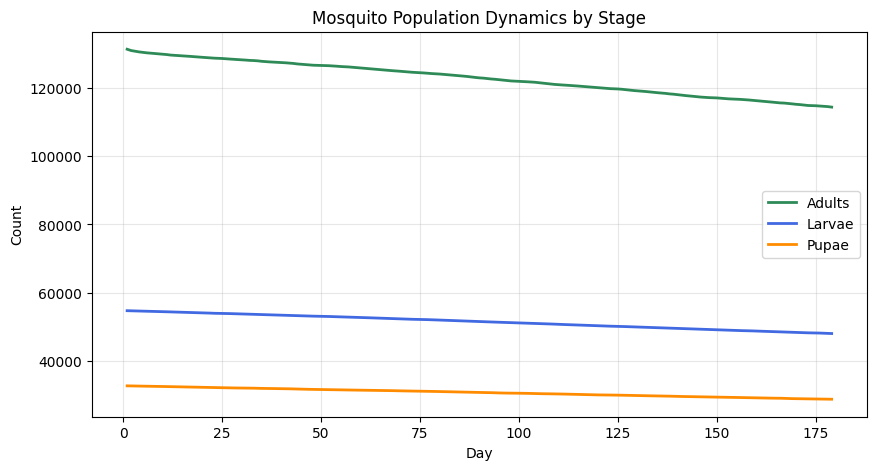

Theoretical larval duration at 26.3°C: 11.38 days
Theoretical pupal duration at 26.3°C: 4.26 days

--- Estimating from simulation data (cross‑correlation method) ---
Data‑based larval duration: not reliable (population still increasing).
Data‑based pupal duration: not reliable (population still increasing).

✅ Adopted larval duration: 11.4 days
✅ Adopted pupal duration: 4.3 days


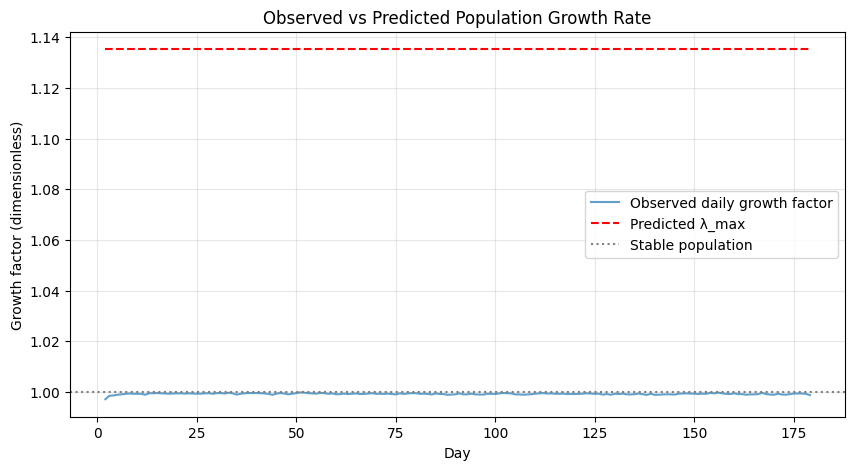

Average predicted λ_max (temp‑dependent adult mortality): 1.135


In [3]:
# ---- Plot population dynamics ----
plt.figure(figsize=(10,5))
plt.plot(daily_living['Day'], daily_living['AdultCount'], label='Adults', color=STAGE_COLORS['ADULT'], linewidth=2)
plt.plot(daily_living['Day'], daily_living['LarvaCount'], label='Larvae', color=STAGE_COLORS['LARVA'], linewidth=2)
plt.plot(daily_living['Day'], daily_living['PupaCount'], label='Pupae', color=STAGE_COLORS['PUPA'], linewidth=2)
plt.xlabel('Day')
plt.ylabel('Count')
plt.title('Mosquito Population Dynamics by Stage')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/mosquito_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# Species parameters – EXACTLY as in simulation.yaml
# ------------------------------------------------------------------
params_species = {
    "egg_dev_rho": 0.005000000000000001,
    "egg_dev_k": 39.20841161317061,
    "egg_dev_Delta": 1.9999999999999998,
    "egg_dev_lambda": -0.854916887158478,
    "larva_dev_a": 2.7054689312186438e-05,
    "larva_dev_Tmin": 5.123026541348266,
    "larva_dev_Tmax": 44.999999999835175,
    "larva_dev_m": 1.663077023745059,
    "pupa_dev_rho": 0.005115463305281753,
    "pupa_dev_k": 39.940257466039114,
    "pupa_dev_Delta": 1.9999999999999998,
    "pupa_dev_lambda": -0.9081661833839708,
    "egg_mort_b1": 3.572876,
    "egg_mort_b2": -0.323474,
    "egg_mort_b3": 0.004941,
    "larva_mort_b1": 1.9999999999999998,
    "larva_mort_b2": -0.7395036647759831,
    "larva_mort_b3": 0.017491023810106067,
    "pupa_mort_b1": 5.882576,
    "pupa_mort_b2": -0.578528,
    "pupa_mort_b3": 0.009458,
    "fecundity_rmax": 1.6021994175985133,
    "fecundity_Topt": 30.634033187663604,
    "fecundity_c": -0.0052723551194922445,
    "adult_mort_b1": -1.4775,
    "adult_mort_b2": -0.1377,
    "adult_mort_b3": 0.003908,
    "adult_mortality_per_day": 0.1198, 
    "sex_ratio": 0.5,
}

# ---- Helper functions (same as simulation's LifecycleModel) ----
def egg_development_rate(T_C):
    rho = params_species['egg_dev_rho']
    k = params_species['egg_dev_k']
    Delta = params_species['egg_dev_Delta']
    lam = params_species['egg_dev_lambda']
    exp_arg = rho * k - (k - T_C) / Delta
    # exp_arg = np.clip(exp_arg, -700, 700)
    val = np.exp(rho * T_C - np.exp(exp_arg)) + lam
    return max(0, val)

def larva_development_rate(T_C):
    a = params_species['larva_dev_a']
    Tmin = params_species['larva_dev_Tmin']
    Tmax = params_species['larva_dev_Tmax']
    m = params_species['larva_dev_m']
    if T_C <= Tmin or T_C >= Tmax:
        return 0.0
    val = a * T_C * (T_C - Tmin) * (Tmax - T_C) ** (1.0/m)
    return max(0, val)

def pupa_development_rate(T_C):
    rho = params_species['pupa_dev_rho']
    k = params_species['pupa_dev_k']
    Delta = params_species['pupa_dev_Delta']
    lam = params_species['pupa_dev_lambda']
    exp_arg = rho * k - (k - T_C) / Delta
    # exp_arg = np.clip(exp_arg, -700, 700)
    val = np.exp(rho * T_C - np.exp(exp_arg)) + lam
    return max(0, val)

def egg_mortality_rate(T_C):
    return np.exp(params_species['egg_mort_b1'] + params_species['egg_mort_b2']*T_C + params_species['egg_mort_b3']*T_C**2)

def larva_mortality_rate(T_C):
    return np.exp(params_species['larva_mort_b1'] + params_species['larva_mort_b2']*T_C + params_species['larva_mort_b3']*T_C**2)

def pupa_mortality_rate(T_C):
    return np.exp(params_species['pupa_mort_b1'] + params_species['pupa_mort_b2']*T_C + params_species['pupa_mort_b3']*T_C**2)

def adult_mortality_rate(T_C):
    # Temperature‑dependent as used in simulation
    return np.exp(params_species['adult_mort_b1'] + params_species['adult_mort_b2']*T_C + params_species['adult_mort_b3']*T_C**2)

def fecundity_rate(T_C):
    rmax = params_species['fecundity_rmax']
    Topt = params_species['fecundity_Topt']
    c = params_species['fecundity_c']
    Sr = params_species['sex_ratio']
    val = np.exp(rmax + c * (Topt - T_C)**2)
    return max(0, val) * Sr

# ---- Theoretical durations at mean temperature ----
def theoretical_duration(rate_func, temp_celsius):
    rate = rate_func(temp_celsius)
    return 1.0 / rate if rate > 0 else np.inf

temp_col = None
for col, disp, _, _, _ in ENV_VARS:
    if 'temp' in col.lower() or disp.lower() == 'temperature':
        temp_col = f'Mean{disp}'
        break

if temp_col is not None and temp_col in daily_living.columns:
    mean_temp = daily_living[temp_col].mean()
    theo_larval = theoretical_duration(larva_development_rate, mean_temp)
    theo_pupal = theoretical_duration(pupa_development_rate, mean_temp)
    print(f"Theoretical larval duration at {mean_temp:.1f}°C: {theo_larval:.2f} days")
    print(f"Theoretical pupal duration at {mean_temp:.1f}°C: {theo_pupal:.2f} days")
else:
    print("Could not compute theoretical durations – temperature column missing.")

# ---- Estimate stage duration from simulation data (cross‑correlation) ----
from scipy.ndimage import uniform_filter1d

def estimate_stage_duration_cross_corr(df, stage_from, stage_to, ticks_per_day=96, smooth_window=5):
    s1 = df[f'{stage_from}Count'].values.astype(float)
    s2 = df[f'{stage_to}Count'].values.astype(float)
    # Ensure same length
    last = max(np.flatnonzero(s1)[-1] if np.any(s1) else 0,
               np.flatnonzero(s2)[-1] if np.any(s2) else 0)
    s1 = s1[:last+1]
    s2 = s2[:last+1]
    if smooth_window > 1:
        s1 = uniform_filter1d(s1, size=smooth_window, mode='nearest')
        s2 = uniform_filter1d(s2, size=smooth_window, mode='nearest')
    # Cross‑correlation
    corr = correlate(s1, s2, mode='full')
    lags = correlation_lags(len(s1), len(s2), mode='full')
    peak_lag = lags[np.argmax(corr)]
    lag_days = peak_lag / ticks_per_day
    return lag_days if lag_days > 0 else None

print("\n--- Estimating from simulation data (cross‑correlation method) ---")
larval_days = estimate_stage_duration_cross_corr(daily_living, 'Larva', 'Pupa', TICKS_PER_DAY)
pupal_days = estimate_stage_duration_cross_corr(daily_living, 'Pupa', 'Adult', TICKS_PER_DAY)

if larval_days:
    print(f"Data‑based larval duration: {larval_days:.1f} days")
else:
    print("Data‑based larval duration: not reliable (population still increasing).")
if pupal_days:
    print(f"Data‑based pupal duration: {pupal_days:.1f} days")
else:
    print("Data‑based pupal duration: not reliable (population still increasing).")

final_larval = larval_days if larval_days else theo_larval
final_pupal = pupal_days if pupal_days else theo_pupal
if final_larval and final_pupal:
    print(f"\n✅ Adopted larval duration: {final_larval:.1f} days")
    print(f"✅ Adopted pupal duration: {final_pupal:.1f} days")
else:
    print("\n⚠️ Could not obtain either estimate – simulation may be too short.")


def discrete_lambda_max(T_C, livestock_density, params):
    rE = egg_development_rate(T_C)
    rL = larva_development_rate(T_C)
    rP = pupa_development_rate(T_C)

    muE = egg_mortality_rate(T_C)
    muL = larva_mortality_rate(T_C)
    muP = pupa_mortality_rate(T_C)
    muA = adult_mortality_rate(T_C)    # temperature‑dependent

    # Daily stage transition probabilities (as in simulation)
    pDevE = 1.0 - np.exp(-rE)
    pSurvE = np.exp(-muE)
    pDevL = 1.0 - np.exp(-rL)
    pSurvL = np.exp(-muL)
    pDevP = 1.0 - np.exp(-rP)
    pSurvP = np.exp(-muP)
    pSurvA = np.exp(-muA)

    F = fecundity_rate(T_C)
    K = 1 + np.log1p(max(0, livestock_density))
    eggs_per_female = F * K

    A_mat = np.array([
        [(1 - pDevE) * pSurvE, 0, 0, eggs_per_female],
        [pDevE * pSurvE, (1 - pDevL) * pSurvL, 0, 0],
        [0, pDevL * pSurvL, (1 - pDevP) * pSurvP, 0],
        [0, 0, pDevP * pSurvP, pSurvA]
    ])

    eigvals = np.linalg.eigvals(A_mat)
    return np.max(eigvals.real)

livestock_density = 0.5   # consistent with simulation default

if temp_col is not None and temp_col in daily_living.columns:
    lambda_vals = [discrete_lambda_max(temp, livestock_density, params_species) for temp in daily_living[temp_col]]
    adult_counts = daily_living['AdultCount'].values
    observed_growth = adult_counts[1:] / (adult_counts[:-1] + 1e-6)
    days_obs = daily_living['Day'].values[1:]

    plt.figure(figsize=(10,5))
    plt.plot(days_obs, observed_growth, label='Observed daily growth factor', alpha=0.7)
    plt.plot(days_obs, lambda_vals[1:], label='Predicted λ_max', linestyle='--', color='red')
    plt.axhline(1, color='gray', linestyle=':', label='Stable population')
    plt.xlabel('Day')
    plt.ylabel('Growth factor (dimensionless)')
    plt.title('Observed vs Predicted Population Growth Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/growth_validation.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Average predicted λ_max (temp‑dependent adult mortality): {np.mean(lambda_vals):.3f}")
else:
    print("No temperature column found – skipping validation.")

# 3. Water Tank Statistics

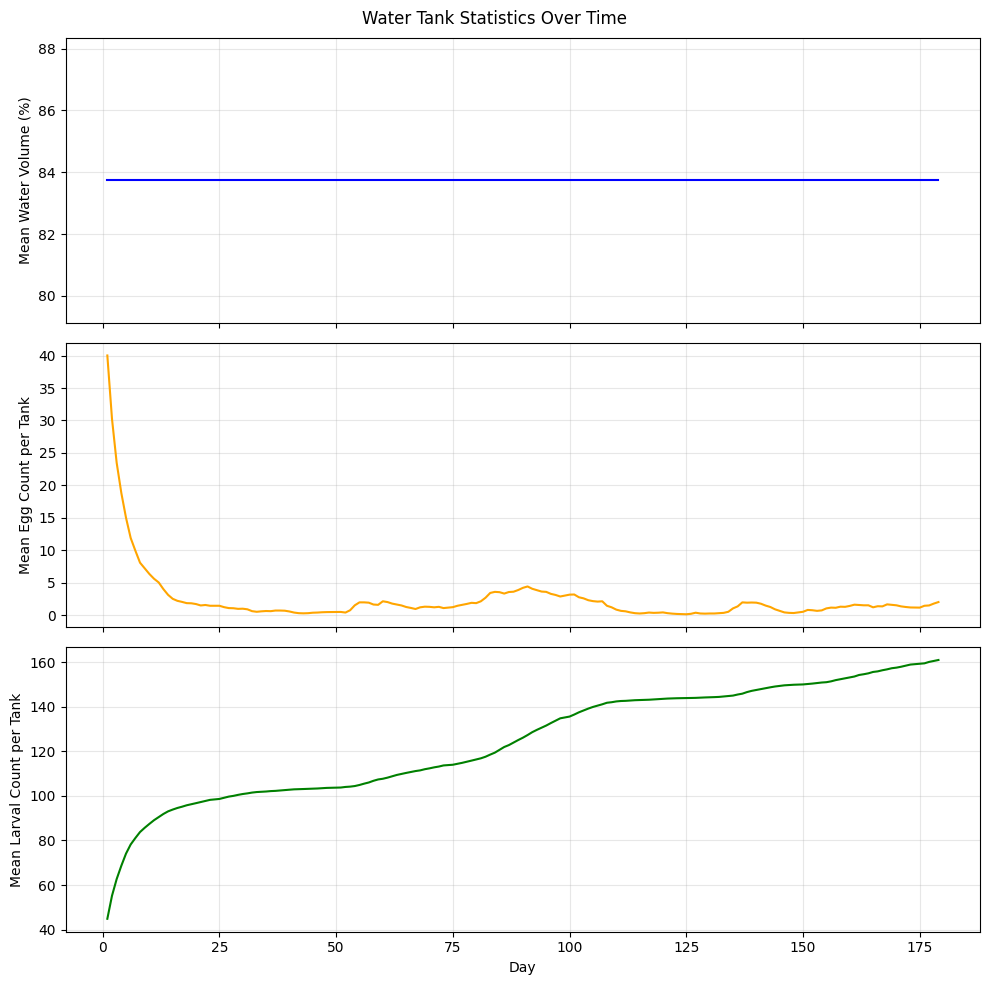

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
axes[0].plot(daily_inert['Day'], daily_inert['MeanWaterVolume'], color='blue')
axes[0].set_ylabel('Mean Water Volume (%)'); axes[0].grid(True, alpha=0.3)
axes[1].plot(daily_inert['Day'], daily_inert['TotalEggs'] / daily_inert['TankCount'].clip(lower=1), color='orange')
axes[1].set_ylabel('Mean Egg Count per Tank'); axes[1].grid(True, alpha=0.3)
axes[2].plot(daily_inert['Day'], daily_inert['TotalLarvae'] / daily_inert['TankCount'].clip(lower=1), color='green')
axes[2].set_ylabel('Mean Larval Count per Tank'); axes[2].set_xlabel('Day'); axes[2].grid(True, alpha=0.3)
plt.suptitle('Water Tank Statistics Over Time')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/tank_stats.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Environmental Correlation

Uses daily aggregated temperature (converted to Celsius) and precipitation (converted to mm).

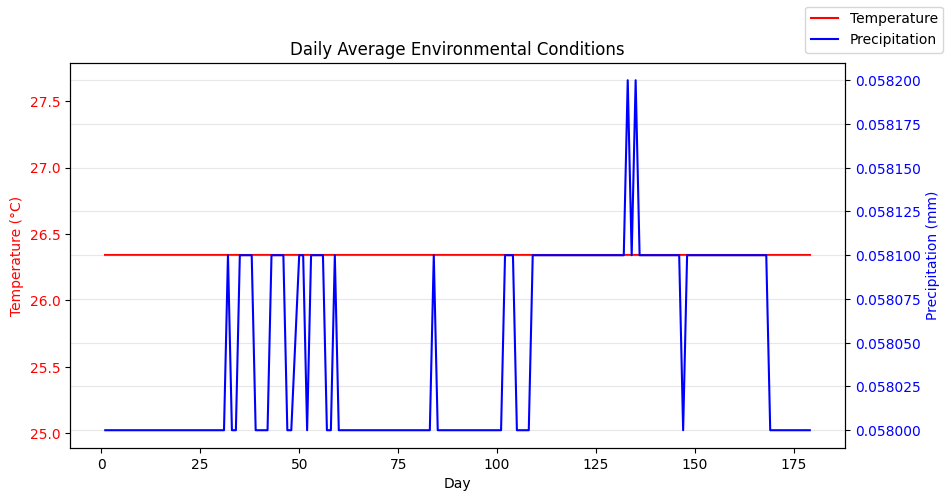

Correlation adult count vs Temperature: r=nan (p=nan)
Correlation adult count vs Precipitation: r=-0.477 (p=3.808e-11)


In [5]:
if len(ENV_VARS) == 1:
    col, disp, unit, _, _ = ENV_VARS[0]
    mean_col = f'Mean{disp}'
    plt.figure(figsize=(10,5))
    plt.plot(daily_living['Day'], daily_living[mean_col], color='red')
    plt.ylabel(f'{disp} ({unit})', color='red')
    plt.xlabel('Day'); plt.title(f'Daily Average {disp}'); plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/environment.png', dpi=300, bbox_inches='tight'); plt.show()
else:
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.set_xlabel('Day')
    axes = [ax1]; colors = ['red','blue','green','orange','purple']
    for i, (col, disp, unit, _, _) in enumerate(ENV_VARS):
        mean_col = f'Mean{disp}'
        if i == 0:
            ax = ax1
            ax.set_ylabel(f'{disp} ({unit})', color=colors[i]); ax.tick_params(axis='y', labelcolor=colors[i])
        else:
            ax = ax1.twinx()
            ax.set_ylabel(f'{disp} ({unit})', color=colors[i]); ax.tick_params(axis='y', labelcolor=colors[i])
            axes.append(ax)
        ax.plot(daily_living['Day'], daily_living[mean_col], color=colors[i], label=disp)
    fig.legend(loc='upper right')
    plt.title('Daily Average Environmental Conditions')
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/environment.png', dpi=300, bbox_inches='tight'); plt.show()

adult_series = daily_living['AdultCount'].values
for col, disp, unit, _, _ in ENV_VARS:
    mean_col = f'Mean{disp}'
    if mean_col in daily_living.columns:
        var_series = daily_living[mean_col].values
        corr, p = pearsonr(adult_series, var_series)
        print(f"Correlation adult count vs {disp}: r={corr:.3f} (p={p:.3e})")

# 5. Suitability Maps & GeoTIFF Export

KDE of adult mosquito positions and rasterised tank load (eggs+larvae) at the last tick.

Adult points collected: 200000
Using last tick 100 for tank load.
Tank load data collected: 42 tanks
KDE extent: x=[38.201406, 48.877952], y=[2.637629, 11.866121]
Adult suitability raster saved to /mnt/monadworld/projects/phd/article_manuscripts/new/figs/somali/adult_suitability.tif


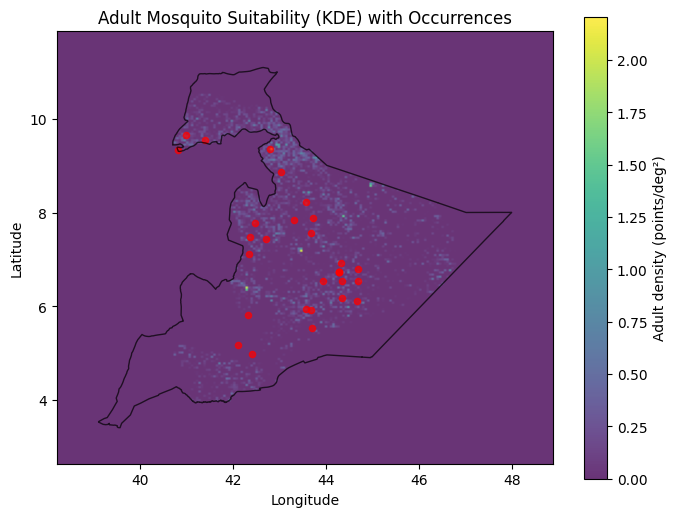

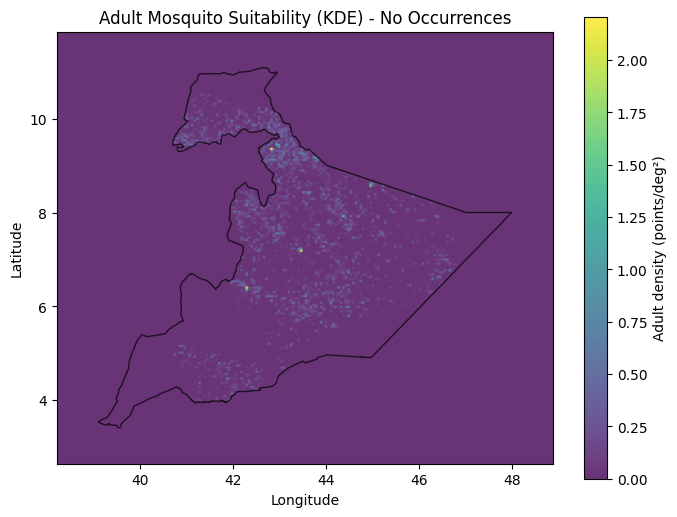

Breeding site potential raster saved to /mnt/monadworld/projects/phd/article_manuscripts/new/figs/somali/breeding_site_potential.tif


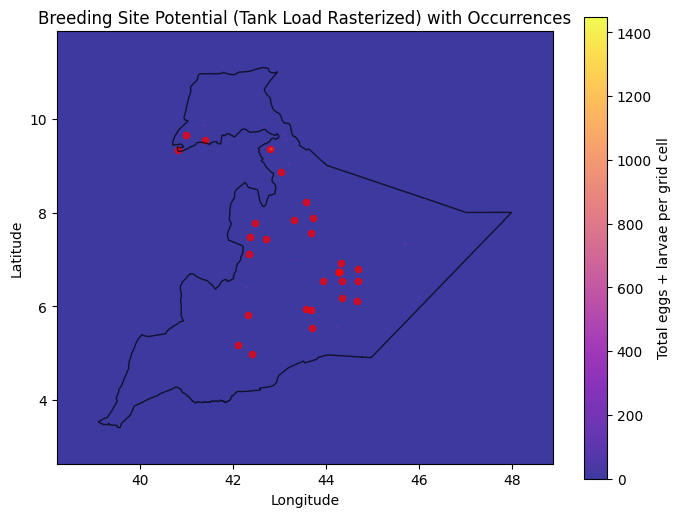

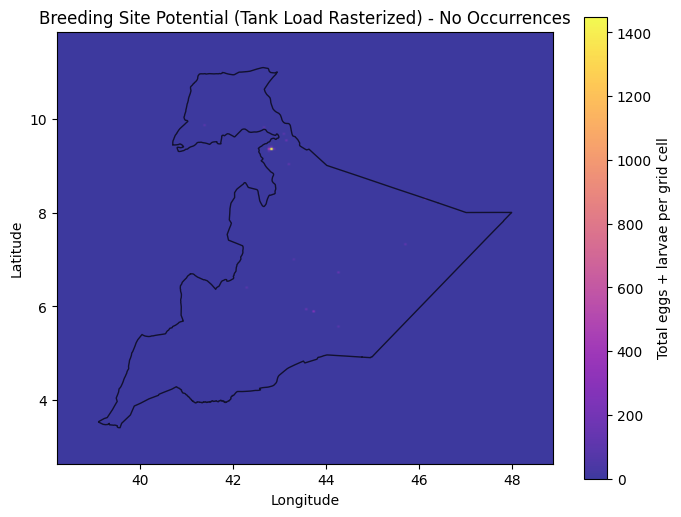

In [6]:
# ----------------------------------------------------------------------
# 1. Accumulate adult positions (spatial sampling)
# ----------------------------------------------------------------------
def accumulate_points(filepath, agent_type, stage=None, max_points=None):
    usecols = ['TickCount', 'AgentType', 'X', 'Y', 'Stage']
    all_points = []
    total = 0
    for chunk in pd.read_csv(filepath, chunksize=CHUNKSIZE, usecols=usecols, low_memory=False):
        mask = (chunk['AgentType'] == agent_type)
        if stage is not None:
            mask = mask & (chunk['Stage'] == stage)
        sub = chunk.loc[mask, ['X', 'Y']]
        if not sub.empty:
            all_points.append(sub)
            total += len(sub)
            if max_points and total >= max_points:
                break
    if not all_points:
        return pd.DataFrame()
    result = pd.concat(all_points, ignore_index=True)
    if max_points and len(result) > max_points:
        result = result.sample(n=max_points, random_state=42)
    return result

MAX_KDE_POINTS = 200000
adult_points = accumulate_points(INPUT_FILE, 'LivingAgent', stage='ADULT', max_points=MAX_KDE_POINTS)
print(f"Adult points collected: {len(adult_points)}")

# ----------------------------------------------------------------------
# 2. Tank load for the last tick
# ----------------------------------------------------------------------
last_tick = None
for chunk in pd.read_csv(INPUT_FILE, chunksize=CHUNKSIZE, usecols=['TickCount', 'AgentType'], low_memory=False):
    last_tick = chunk['TickCount'].max()
    break
print(f"Using last tick {last_tick} for tank load.")
tanks_load = []
for chunk in pd.read_csv(INPUT_FILE, chunksize=CHUNKSIZE, usecols=['TickCount', 'AgentType', 'X', 'Y', 'EggCount', 'LarvaCount'], low_memory=False):
    mask = (chunk['TickCount'] == last_tick) & (chunk['AgentType'] == 'InertAgent')
    sub = chunk.loc[mask, ['X', 'Y', 'EggCount', 'LarvaCount']]
    if not sub.empty:
        tanks_load.append(sub)
        if sum(len(df) for df in tanks_load) > 200000:
            break
if tanks_load:
    tanks_load_df = pd.concat(tanks_load, ignore_index=True)
    tanks_load_df['Load'] = tanks_load_df['EggCount'] + tanks_load_df['LarvaCount']
else:
    tanks_load_df = pd.DataFrame()
print(f"Tank load data collected: {len(tanks_load_df)} tanks")

# ----------------------------------------------------------------------
# 3. KDE creation (adults)
# ----------------------------------------------------------------------
def create_kde_suitability(points, bandwidth_deg=KDE_BANDWIDTH_DEG, grid_res=KDE_GRID_RES):
    if len(points) < 10:
        return None, None, None, None
    if study_area is not None:
        xmin, ymin, xmax, ymax = study_area.total_bounds
    else:
        xmin, xmax = points['X'].min(), points['X'].max()
        ymin, ymax = points['Y'].min(), points['Y'].max()
    dx = (xmax - xmin) * 0.1
    dy = (ymax - ymin) * 0.1
    xmin -= dx; xmax += dx; ymin -= dy; ymax += dy

    x = np.linspace(xmin, xmax, grid_res)
    y = np.linspace(ymin, ymax, grid_res)
    xx, yy = np.meshgrid(x, y)
    grid = np.vstack([xx.ravel(), yy.ravel()]).T
    kde = KernelDensity(bandwidth=bandwidth_deg, metric='euclidean')
    kde.fit(points[['X','Y']].values)
    log_dens = kde.score_samples(grid)
    dens = np.exp(log_dens).reshape(xx.shape)
    return xx, yy, dens, (xmin, xmax, ymin, ymax)

adult_kde = create_kde_suitability(adult_points)

if adult_kde[0] is not None:
    xx, yy, dens, (xmin, xmax, ymin, ymax) = adult_kde

    # ------------------------------------------------------------------
    # 4. Ensure CRS consistency
    # ------------------------------------------------------------------
    if study_area is not None:
        if study_area.crs is None:
            study_area.crs = "EPSG:4326"
        elif study_area.crs.to_epsg() != 4326:
            study_area = study_area.to_crs("EPSG:4326")
    if occurrences is not None:
        if occurrences.crs is None:
            occurrences.crs = "EPSG:4326"
        elif occurrences.crs.to_epsg() != 4326:
            occurrences = occurrences.to_crs("EPSG:4326")

    print(f"KDE extent: x=[{xmin:.6f}, {xmax:.6f}], y=[{ymin:.6f}, {ymax:.6f}]")

    # ------------------------------------------------------------------
    # 5. Export GeoTIFF (NO FLIP)
    # ------------------------------------------------------------------
    if EXPORT_RASTERS:
        transform = from_origin(xmin, ymax,
                                (xmax - xmin) / dens.shape[1],
                                (ymax - ymin) / dens.shape[0])
        adult_tif = os.path.join(OUTPUT_DIR, 'adult_suitability.tif')
        with rasterio.open(adult_tif, 'w', driver='GTiff',
                           height=dens.shape[0], width=dens.shape[1],
                           count=1, dtype=dens.dtype, crs='EPSG:4326',
                           transform=transform) as dst:
            dst.write(dens, 1)
        print(f"Adult suitability raster saved to {adult_tif}")

        # Read back for plotting
        with rasterio.open(adult_tif) as src:
            dens_geo = src.read(1)
            bounds = src.bounds
            xmin_geo, ymin_geo, xmax_geo, ymax_geo = bounds.left, bounds.bottom, bounds.right, bounds.top

        fig, ax = plt.subplots(figsize=(8,6))
        im = ax.imshow(dens_geo, extent=[xmin_geo, xmax_geo, ymin_geo, ymax_geo],
                       origin='upper', cmap='viridis', alpha=0.8)
        if study_area is not None:
            study_area.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.7)
        if occurrences is not None:
            occurrences.plot(ax=ax, color='red', marker='o', markersize=20,
                             alpha=0.7, label='Occurrences')
        plt.colorbar(im, label='Adult density (points/deg²)')
        plt.title('Adult Mosquito Suitability (KDE) with Occurrences')
        plt.xlabel('Longitude'); plt.ylabel('Latitude')
        plt.savefig(f'{OUTPUT_DIR}/adult_suitability.png', dpi=300, bbox_inches='tight')
        plt.show()

        fig, ax = plt.subplots(figsize=(8,6))
        im = ax.imshow(dens_geo, extent=[xmin_geo, xmax_geo, ymin_geo, ymax_geo],
                       origin='upper', cmap='viridis', alpha=0.8)
        if study_area is not None:
            study_area.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.7)
        plt.colorbar(im, label='Adult density (points/deg²)')
        plt.title('Adult Mosquito Suitability (KDE) - No Occurrences')
        plt.xlabel('Longitude'); plt.ylabel('Latitude')
        plt.savefig(f'{OUTPUT_DIR}/adult_suitability_no_occurrences.png', dpi=300, bbox_inches='tight')
        plt.show()

# ----------------------------------------------------------------------
# 6. Tank load raster (same grid as KDE)
# ----------------------------------------------------------------------
if not tanks_load_df.empty and EXPORT_RASTERS and adult_kde[0] is not None:
    grid_res = KDE_GRID_RES
    x_edges = np.linspace(xmin, xmax, grid_res + 1)
    y_edges = np.linspace(ymin, ymax, grid_res + 1)

    load_raster, _, _ = np.histogram2d(tanks_load_df['X'], tanks_load_df['Y'],
                                       bins=[x_edges, y_edges],
                                       weights=tanks_load_df['Load'])
    load_raster = load_raster.T

    transform = from_origin(xmin, ymax,
                            (xmax - xmin) / grid_res,
                            (ymax - ymin) / grid_res)
    tank_tif = os.path.join(OUTPUT_DIR, 'breeding_site_potential.tif')
    with rasterio.open(tank_tif, 'w', driver='GTiff',
                       height=grid_res, width=grid_res,
                       count=1, dtype=load_raster.dtype, crs='EPSG:4326',
                       transform=transform) as dst:
        dst.write(load_raster, 1)
    print(f"Breeding site potential raster saved to {tank_tif}")

    with rasterio.open(tank_tif) as src:
        tank_geo = src.read(1)
        bounds = src.bounds
        xmin_t, ymin_t, xmax_t, ymax_t = bounds.left, bounds.bottom, bounds.right, bounds.top

    fig, ax = plt.subplots(figsize=(8,6))
    im = ax.imshow(tank_geo, extent=[xmin_t, xmax_t, ymin_t, ymax_t],
                   origin='upper', cmap='plasma', alpha=0.8)
    if study_area is not None:
        study_area.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.7)
    if occurrences is not None:
        occurrences.plot(ax=ax, color='red', marker='o', markersize=20,
                         alpha=0.7, label='Occurrences')
    plt.colorbar(im, label='Total eggs + larvae per grid cell')
    plt.title('Breeding Site Potential (Tank Load Rasterized) with Occurrences')
    plt.xlabel('Longitude'); plt.ylabel('Latitude')
    plt.savefig(f'{OUTPUT_DIR}/breeding_site_potential.png', dpi=300, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(8,6))
    im = ax.imshow(tank_geo, extent=[xmin_t, xmax_t, ymin_t, ymax_t],
                   origin='upper', cmap='plasma', alpha=0.8)
    if study_area is not None:
        study_area.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.7)
    plt.colorbar(im, label='Total eggs + larvae per grid cell')
    plt.title('Breeding Site Potential (Tank Load Rasterized) - No Occurrences')
    plt.xlabel('Longitude'); plt.ylabel('Latitude')
    plt.savefig(f'{OUTPUT_DIR}/breeding_site_potential_no_occurrences.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No tank load data or KDE missing – cannot export breeding site raster.")

# 6. Validation against Real Occurrence Data (Boyce Index & Proportion in top 20%)

In [7]:
if occurrences is not None and adult_kde[0] is not None:
    xx, yy, dens, _ = adult_kde
    x_grid = xx[0,:]
    y_grid = yy[:,0]
    occ_coords = np.array([[geom.x, geom.y] for geom in occurrences.geometry])
    interp = RegularGridInterpolator((y_grid, x_grid), dens, bounds_error=False, fill_value=0)
    occ_dens = interp(occ_coords[:, [1,0]])
    threshold = np.percentile(dens[dens>0], 80)
    high_suit = occ_dens >= threshold
    accuracy = np.mean(high_suit) * 100
    print(f"Proportion of occurrence points in top 20% adult suitability: {accuracy:.1f}%")
    
    # Continuous Boyce Index
    def continuous_boyce_index(suit_raster, x_grid, y_grid, occ_coords, n_bins=20):
        suit_flat = suit_raster.ravel()
        suit_min, suit_max = np.percentile(suit_flat[suit_flat>0], [1,99])
        if suit_min == suit_max:
            suit_min = suit_flat.min()
            suit_max = suit_flat.max()
        bins = np.linspace(suit_min, suit_max, n_bins+1)
        # Expected: area proportion
        flat = suit_raster.ravel()
        area_counts = np.histogram(flat, bins=bins)[0]
        expected = area_counts / area_counts.sum()
        # Observed: occurrence proportion
        occ_vals = interp(occ_coords[:, [1,0]])
        obs_counts = np.histogram(occ_vals, bins=bins)[0]
        observed = obs_counts / obs_counts.sum()
        valid = expected > 0
        if not valid.any():
            return np.nan
        return spearmanr(observed[valid], expected[valid])[0]

    boyce = continuous_boyce_index(dens, x_grid, y_grid, occ_coords)
    print(f"Continuous Boyce Index = {boyce:.3f}")
else:
    print("Occurrence data or suitability KDE missing – cannot compute validation.")

Proportion of occurrence points in top 20% adult suitability: 36.7%
Continuous Boyce Index = 0.782


# 7. Export Tidy Data (Daily summary and a sample of the raw CSV)

In [8]:
daily_summary = pd.merge(daily_living, daily_inert, on='Day', how='outer')
daily_summary.to_csv(f'{OUTPUT_DIR}/daily_summary.csv', index=False)
sample_df = pd.read_csv(INPUT_FILE, nrows=10000)
sample_df.to_csv(f'{OUTPUT_DIR}/living_sample.csv', index=False)
print(f"Summaries saved to {OUTPUT_DIR}/")
print("Files: daily_summary.csv, living_sample.csv")
print("Analysis complete. All figures and rasters saved.")
sample_df.describe()

Summaries saved to /mnt/monadworld/projects/phd/article_manuscripts/new/figs/somali/
Files: daily_summary.csv, living_sample.csv
Analysis complete. All figures and rasters saved.


,TickCount,X,Y,Alive,Age,Energy,Gravid,EggCount,LarvaCount,waterVolume,Resting,RestingDuration,TimeWithoutRest,Elevation,Buildings,Population,tp,t2m
count,10000.0,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,10000.000000,10000.0,10000.0,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,100.0,43.216931,6.776731,1.0,717.302000,0.615403,0.120200,0.0,0.0,0.0,0.186400,0.282600,0.081600,891.007100,0.005700,58.296639,0.056624,26.354957
std,0.0,1.280395,1.627600,0.0,552.384106,0.152805,0.325212,0.0,0.0,0.0,0.389449,0.772915,2.076577,444.069479,0.102316,1034.197934,0.182866,2.759420
min,100.0,40.705789,3.947026,1.0,0.000000,0.300000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,-99999.000000,0.000000,16.950000
25%,100.0,42.327724,5.306476,1.0,228.000000,0.505000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,493.000000,0.000000,12.176425,0.000000,24.520000
50%,100.0,43.065556,6.614154,1.0,604.500000,0.635000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,871.000000,0.000000,25.290500,0.000000,27.080000
75%,100.0,44.009523,8.083738,1.0,1121.250000,0.735000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,1189.000000,0.000000,54.604150,0.000000,28.330000
max,100.0,46.781712,10.542753,1.0,1919.000000,1.000000,1.000000,0.0,0.0,0.0,1.000000,5.000000,95.000000,2220.000000,4.000000,6774.002900,1.246900,31.370000
